In [ ]:
# Water Tank / Water Pouring Problem Solver
# AI Mini Project

print("💧 Water Tank / Water Pouring Problem Solver")
print("Project initialized successfully!")

💧 Water Tank / Water Pouring Problem Solver
Project initialized successfully!


In [ ]:
!pip -q install gradio matplotlib pandas

In [ ]:
from collections import deque

def solve(A, B, target):

    q = deque([(0, 0)])
    visited = {(0, 0)}
    parent = {(0, 0): None}
    action = {(0, 0): "Start"}

    while q:

        x, y = q.popleft()

        if x == target or y == target:

            path = []
            state = (x, y)

            while state is not None:
                path.append((state, action[state]))
                state = parent[state]

            return path[::-1]

        moves = [
            ((A, y), "Fill A"),
            ((x, B), "Fill B"),
            ((0, y), "Empty A"),
            ((x, 0), "Empty B"),
            ((x-min(x, B-y), y+min(x, B-y)), "Pour A -> B"),
            ((x+min(y, A-x), y-min(y, A-x)), "Pour B -> A")
        ]

        for new_state, move in moves:

            if new_state not in visited:

                visited.add(new_state)
                q.append(new_state)
                parent[new_state] = (x, y)
                action[new_state] = move

    return None


# Test
solution = solve(4, 3, 2)

print("💧 WATER POURING SOLVER")
print("-----------------------")

for i, (state, move) in enumerate(solution):
    print(f"Step {i}: {move} -> A={state[0]}L, B={state[1]}L")

💧 WATER POURING SOLVER
-----------------------
Step 0: Start -> A=0L, B=0L
Step 1: Fill B -> A=0L, B=3L
Step 2: Pour B -> A -> A=3L, B=0L
Step 3: Fill B -> A=3L, B=3L
Step 4: Pour B -> A -> A=4L, B=2L


In [ ]:
def water_tank_solver(tank_capacity, current_water, target_water,
                      inlet_rate, outlet_rate):

    print("🚰 WATER TANK SOLVER")
    print("----------------------------")

    # Check valid input
    if current_water > tank_capacity:
        print("❌ Current water cannot exceed tank capacity.")
        return

    if target_water > tank_capacity:
        print("❌ Target water cannot exceed tank capacity.")
        return

    if inlet_rate < 0 or outlet_rate < 0:
        print("❌ Rates cannot be negative.")
        return

    # Net water rate
    net_rate = inlet_rate - outlet_rate

    # Target already reached
    if current_water == target_water:
        print("✅ Target water level already reached.")
        print("⏱️ Time required: 0 minutes")
        return

    # Tank needs filling
    if target_water > current_water:

        if net_rate <= 0:
            print("❌ Target cannot be reached.")
            print("Inlet rate must be greater than outlet rate.")
            return

        required_water = target_water - current_water
        time_required = required_water / net_rate

        print(f"Current water     : {current_water} L")
        print(f"Target water      : {target_water} L")
        print(f"Inlet rate        : {inlet_rate} L/min")
        print(f"Outlet rate       : {outlet_rate} L/min")
        print(f"Net rate          : {net_rate} L/min")
        print(f"Water required    : {required_water} L")
        print(f"⏱️ Time required  : {time_required:.2f} minutes")

    # Tank needs draining
    else:

        drain_rate = outlet_rate - inlet_rate

        if drain_rate <= 0:
            print("❌ Target cannot be reached.")
            print("Outlet rate must be greater than inlet rate.")
            return

        required_water = current_water - target_water
        time_required = required_water / drain_rate

        print(f"Current water     : {current_water} L")
        print(f"Target water      : {target_water} L")
        print(f"Inlet rate        : {inlet_rate} L/min")
        print(f"Outlet rate       : {outlet_rate} L/min")
        print(f"Net drain rate    : {drain_rate} L/min")
        print(f"Water to drain    : {required_water} L")
        print(f"⏱️ Time required  : {time_required:.2f} minutes")


# Example
water_tank_solver(
    tank_capacity=1000,
    current_water=200,
    target_water=800,
    inlet_rate=100,
    outlet_rate=20
)

🚰 WATER TANK SOLVER
----------------------------
Current water     : 200 L
Target water      : 800 L
Inlet rate        : 100 L/min
Outlet rate       : 20 L/min
Net rate          : 80 L/min
Water required    : 600 L
⏱️ Time required  : 7.50 minutes


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128688 (\N{POTABLE WATER SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


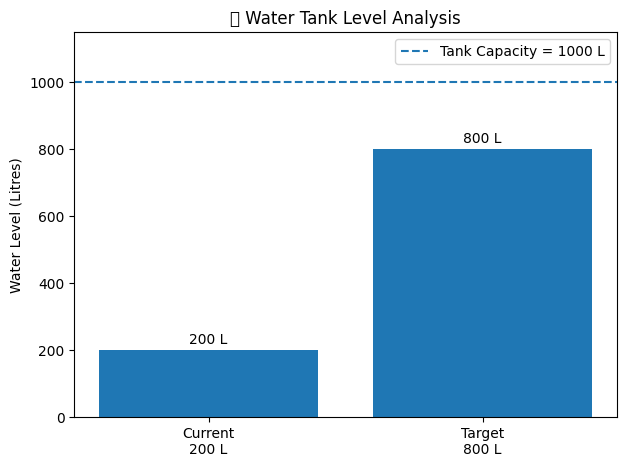

In [ ]:
import matplotlib.pyplot as plt

def visualize_tank(current_water, target_water, tank_capacity):

    levels = [current_water, target_water]

    labels = [
        f"Current\n{current_water} L",
        f"Target\n{target_water} L"
    ]

    plt.figure(figsize=(7, 5))

    bars = plt.bar(labels, levels)

    plt.axhline(
        y=tank_capacity,
        linestyle="--",
        label=f"Tank Capacity = {tank_capacity} L"
    )

    plt.ylabel("Water Level (Litres)")
    plt.title("🚰 Water Tank Level Analysis")

    plt.ylim(0, tank_capacity * 1.15)

    for bar, value in zip(bars, levels):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + tank_capacity * 0.02,
            f"{value} L",
            ha="center"
        )

    plt.legend()
    plt.show()


# Example
visualize_tank(
    current_water=200,
    target_water=800,
    tank_capacity=1000
)

🪣 WATER POURING VISUALIZATION
--------------------------------


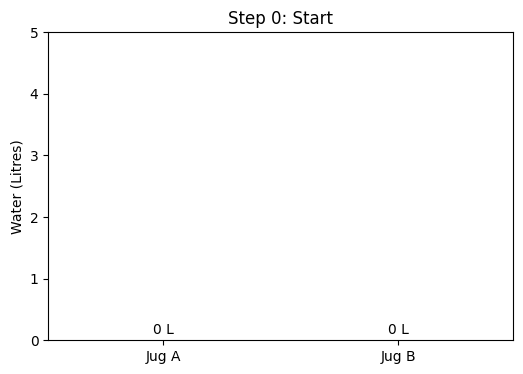

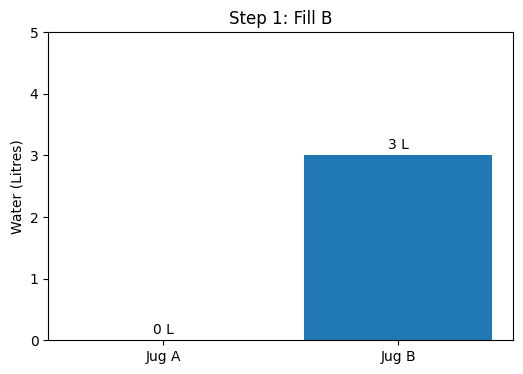

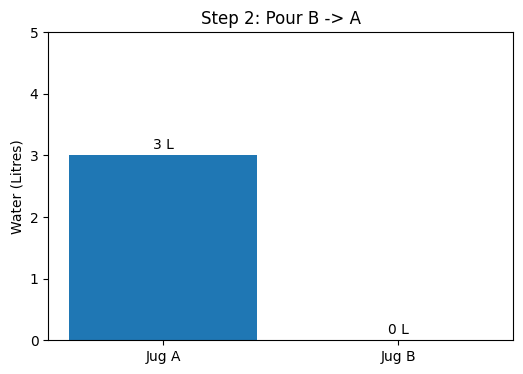

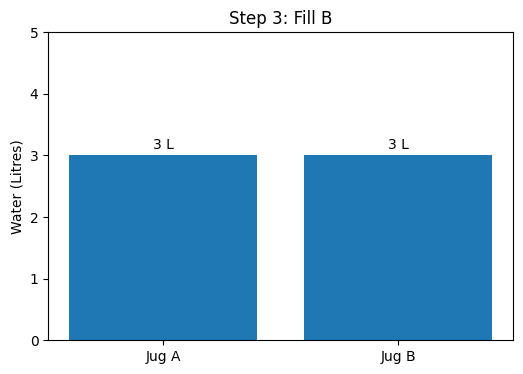

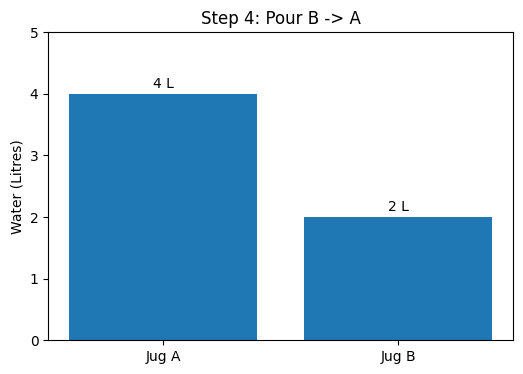

In [ ]:
import matplotlib.pyplot as plt

def show_pouring_solution(solution, capacity_a, capacity_b):

    print("🪣 WATER POURING VISUALIZATION")
    print("--------------------------------")

    for i, (state, move) in enumerate(solution):

        a, b = state

        plt.figure(figsize=(6, 4))

        plt.bar(
            ["Jug A", "Jug B"],
            [a, b]
        )

        plt.ylim(0, max(capacity_a, capacity_b) + 1)
        plt.ylabel("Water (Litres)")
        plt.title(f"Step {i}: {move}")

        for j, value in enumerate([a, b]):
            plt.text(j, value + 0.1, f"{value} L", ha="center")

        plt.show()


# Use our previous solution
show_pouring_solution(
    solution,
    capacity_a=4,
    capacity_b=3
)

In [ ]:
import heapq
import time

def astar_water_pouring(A, B, target):

    start_time = time.perf_counter()

    start = (0, 0)

    # Priority queue
    pq = [(0, 0, start)]

    visited = set()

    parent = {start: None}
    action = {start: "Start"}

    cost_so_far = {start: 0}

    while pq:

        _, cost, state = heapq.heappop(pq)

        x, y = state

        if state in visited:
            continue

        visited.add(state)

        # Target reached
        if x == target or y == target:

            path = []
            current = state

            while current is not None:
                path.append((current, action[current]))
                current = parent[current]

            path.reverse()

            execution_time = time.perf_counter() - start_time

            return path, len(visited), execution_time

        moves = [
            ((A, y), "Fill A"),
            ((x, B), "Fill B"),
            ((0, y), "Empty A"),
            ((x, 0), "Empty B"),
            ((x - min(x, B-y),
              y + min(x, B-y)), "Pour A -> B"),
            ((x + min(y, A-x),
              y - min(y, A-x)), "Pour B -> A")
        ]

        for new_state, move in moves:

            if new_state in visited:
                continue

            new_cost = cost + 1

            # Heuristic: distance from target
            heuristic = min(
                abs(new_state[0] - target),
                abs(new_state[1] - target)
            )

            priority = new_cost + heuristic

            if new_state not in cost_so_far or new_cost < cost_so_far[new_state]:

                cost_so_far[new_state] = new_cost

                heapq.heappush(
                    pq,
                    (priority, new_cost, new_state)
                )

                parent[new_state] = state
                action[new_state] = move

    return None, len(visited), time.perf_counter() - start_time


# Test A*
astar_solution, states, execution_time = astar_water_pouring(
    4, 3, 2
)

print("🧠 A* WATER POURING SOLVER")
print("---------------------------")

if astar_solution:

    for i, (state, move) in enumerate(astar_solution):
        print(
            f"Step {i}: {move} -> "
            f"A={state[0]}L, B={state[1]}L"
        )

    print("\n📊 Performance")
    print("---------------------------")
    print("States explored :", states)
    print(f"Execution time  : {execution_time:.6f} seconds")

else:
    print("❌ No solution possible.")

🧠 A* WATER POURING SOLVER
---------------------------
Step 0: Start -> A=0L, B=0L
Step 1: Fill B -> A=0L, B=3L
Step 2: Pour B -> A -> A=3L, B=0L
Step 3: Fill B -> A=3L, B=3L
Step 4: Pour B -> A -> A=4L, B=2L

📊 Performance
---------------------------
States explored : 9
Execution time  : 0.000052 seconds


In [ ]:
import time

def bfs_performance(A, B, target):

    start_time = time.perf_counter()

    solution = solve(A, B, target)

    end_time = time.perf_counter()

    return len(solution) - 1, end_time - start_time


# BFS
bfs_steps, bfs_time = bfs_performance(4, 3, 2)

# A*
astar_steps = len(astar_solution) - 1

print("📊 BFS vs A* COMPARISON")
print("========================")
print(f"BFS steps       : {bfs_steps}")
print(f"A* steps        : {astar_steps}")
print(f"BFS time        : {bfs_time:.6f} sec")
print(f"A* time         : {execution_time:.6f} sec")
print(f"A* states       : {states}")

📊 BFS vs A* COMPARISON
BFS steps       : 4
A* steps        : 4
BFS time        : 0.000043 sec
A* time         : 0.000052 sec
A* states       : 9


In [ ]:
import gradio as gr

def pouring_gui(capacity_a, capacity_b, target):

    try:
        A = int(capacity_a)
        B = int(capacity_b)
        T = int(target)
    except:
        return "❌ Please enter valid whole numbers."

    if A <= 0 or B <= 0 or T < 0:
        return "❌ Capacities must be positive and target cannot be negative."

    if T > max(A, B):
        return "❌ Target cannot be greater than both jug capacities."

    solution = solve(A, B, T)

    if solution is None:
        return (
            "❌ No solution possible.\n\n"
            "Try another target or jug capacity."
        )

    result = "💧 WATER POURING SOLVER\n"
    result += "========================\n\n"

    for i, (state, move) in enumerate(solution):

        result += (
            f"Step {i}: {move} → "
            f"Jug A = {state[0]}L, "
            f"Jug B = {state[1]}L\n"
        )

    result += "\n✅ Target reached successfully!"

    return result


with gr.Blocks() as app:

    gr.Markdown(
        """
        # 💧 Water Tank / Water Pouring Problem Solver
        ### AI-Based Water Pouring Module
        """
    )

    gr.Markdown(
        "Enter jug capacities and target amount."
    )

    with gr.Row():

        capacity_a = gr.Number(
            label="Jug A Capacity (L)",
            value=4
        )

        capacity_b = gr.Number(
            label="Jug B Capacity (L)",
            value=3
        )

        target = gr.Number(
            label="Target Amount (L)",
            value=2
        )

    solve_button = gr.Button(
        "🧠 Solve Problem",
        variant="primary"
    )

    output = gr.Textbox(
        label="Solution Steps",
        lines=12
    )

    solve_button.click(
        fn=pouring_gui,
        inputs=[capacity_a, capacity_b, target],
        outputs=output
    )


app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3ace84c0d1a73c71dc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr


def combined_solver(mode,
                    jug_a=4,
                    jug_b=3,
                    target=2,
                    tank_capacity=1000,
                    current_water=200,
                    target_water=800,
                    inlet_rate=100,
                    outlet_rate=20):

    # =========================
    # WATER POURING MODE
    # =========================

    if mode == "Water Pouring":

        A = int(jug_a)
        B = int(jug_b)
        T = int(target)

        if A <= 0 or B <= 0:
            return "❌ Jug capacities must be positive."

        if T < 0 or T > max(A, B):
            return "❌ Invalid target amount."

        solution = solve(A, B, T)

        if solution is None:
            return "❌ No solution possible for these capacities."

        result = "🪣 WATER POURING SOLVER\n"
        result += "========================\n\n"

        result += f"Jug A Capacity : {A} L\n"
        result += f"Jug B Capacity : {B} L\n"
        result += f"Target         : {T} L\n\n"

        for i, (state, move) in enumerate(solution):

            result += (
                f"Step {i}: {move} → "
                f"A={state[0]}L, B={state[1]}L\n"
            )

        result += "\n✅ Target reached successfully!"

        return result


    # =========================
    # WATER TANK MODE
    # =========================

    if mode == "Water Tank":

        capacity = float(tank_capacity)
        current = float(current_water)
        target_level = float(target_water)
        inlet = float(inlet_rate)
        outlet = float(outlet_rate)

        if capacity <= 0:
            return "❌ Tank capacity must be positive."

        if current < 0 or current > capacity:
            return "❌ Invalid current water level."

        if target_level < 0 or target_level > capacity:
            return "❌ Invalid target water level."

        if inlet < 0 or outlet < 0:
            return "❌ Rates cannot be negative."

        if current == target_level:

            return (
                "🚰 WATER TANK SOLVER\n"
                "====================\n\n"
                "✅ Target level already reached!\n"
                "⏱️ Time required: 0 minutes"
            )

        # Filling
        if target_level > current:

            net_rate = inlet - outlet

            if net_rate <= 0:

                return (
                    "🚰 WATER TANK SOLVER\n"
                    "====================\n\n"
                    "❌ Target cannot be reached.\n"
                    "Inlet rate must be greater than outlet rate."
                )

            required = target_level - current
            required_time = required / net_rate

            return (
                "🚰 WATER TANK SOLVER\n"
                "====================\n\n"
                f"Tank Capacity : {capacity} L\n"
                f"Current Level : {current} L\n"
                f"Target Level  : {target_level} L\n"
                f"Inlet Rate    : {inlet} L/min\n"
                f"Outlet Rate   : {outlet} L/min\n"
                f"Net Rate      : {net_rate} L/min\n\n"
                f"Water Needed  : {required} L\n"
                f"⏱️ Time        : {required_time:.2f} minutes\n\n"
                "✅ Target level can be reached!"
            )

        # Draining
        else:

            net_rate = outlet - inlet

            if net_rate <= 0:

                return (
                    "🚰 WATER TANK SOLVER\n"
                    "====================\n\n"
                    "❌ Target cannot be reached.\n"
                    "Outlet rate must be greater than inlet rate."
                )

            required = current - target_level
            required_time = required / net_rate

            return (
                "🚰 WATER TANK SOLVER\n"
                "====================\n\n"
                f"Tank Capacity : {capacity} L\n"
                f"Current Level : {current} L\n"
                f"Target Level  : {target_level} L\n"
                f"Inlet Rate    : {inlet} L/min\n"
                f"Outlet Rate   : {outlet} L/min\n"
                f"Net Drain Rate: {net_rate} L/min\n\n"
                f"Water to Drain: {required} L\n"
                f"⏱️ Time        : {required_time:.2f} minutes\n\n"
                "✅ Target level can be reached!"
            )


# =========================
# FINAL COMBINED GUI
# =========================

with gr.Blocks() as final_app:

    gr.Markdown(
        """
        # 💧 Water Tank / Water Pouring Problem Solver
        ### 🧠 AI-Based Problem Solving System
        """
    )

    mode = gr.Radio(
        ["Water Pouring", "Water Tank"],
        value="Water Pouring",
        label="Select Problem Type"
    )

    gr.Markdown("### 🪣 Water Pouring Inputs")

    with gr.Row():

        jug_a = gr.Number(
            label="Jug A Capacity (L)",
            value=4
        )

        jug_b = gr.Number(
            label="Jug B Capacity (L)",
            value=3
        )

        target = gr.Number(
            label="Target Amount (L)",
            value=2
        )

    gr.Markdown("### 🚰 Water Tank Inputs")

    with gr.Row():

        tank_capacity = gr.Number(
            label="Tank Capacity (L)",
            value=1000
        )

        current_water = gr.Number(
            label="Current Water (L)",
            value=200
        )

        target_water = gr.Number(
            label="Target Water (L)",
            value=800
        )

    with gr.Row():

        inlet_rate = gr.Number(
            label="Inlet Rate (L/min)",
            value=100
        )

        outlet_rate = gr.Number(
            label="Outlet Rate (L/min)",
            value=20
        )

    solve_button = gr.Button(
        "🧠 SOLVE PROBLEM",
        variant="primary"
    )

    output = gr.Textbox(
        label="Solver Result",
        lines=15
    )

    solve_button.click(
        fn=combined_solver,
        inputs=[
            mode,
            jug_a,
            jug_b,
            target,
            tank_capacity,
            current_water,
            target_water,
            inlet_rate,
            outlet_rate
        ],
        outputs=output
    )


final_app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://57406e2c5e9b62a2fb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


🧪 WATER POURING TEST RESULTS


,Type,Input,Status,Steps,Time (ms)
0,Water Pouring,"4L, 3L → 2L",Success,4,0.0506
1,Water Pouring,"5L, 3L → 4L",Success,6,0.0391
2,Water Pouring,"7L, 4L → 2L",Success,8,0.0467
3,Water Pouring,"8L, 5L → 3L",Success,2,0.0141
4,Water Pouring,"9L, 6L → 3L",Success,2,0.0139


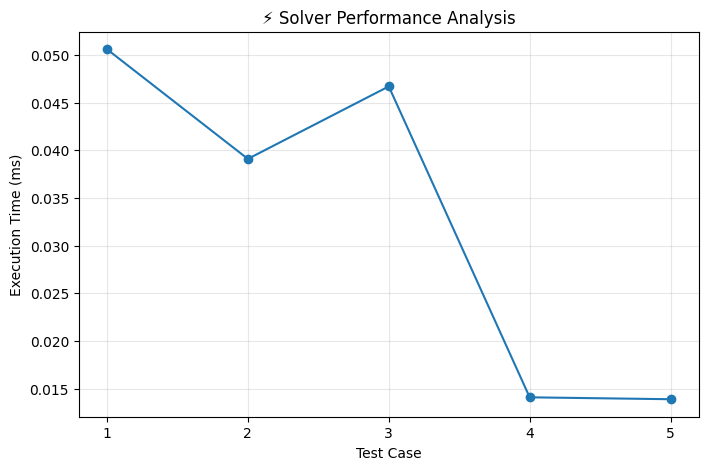


📊 PERFORMANCE SUMMARY
Total Test Cases : 5
Successful Cases : 5
Success Rate     : 100.00%
Average Time     : 0.0329 ms

✅ Step 11 Testing Completed!


In [ ]:
# ============================================================
# STEP 11 - TESTING & PERFORMANCE ANALYSIS
# ============================================================

import time
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# WATER POURING TEST
# ------------------------------------------------------------

def test_pouring(cap_a, cap_b, target):

    start = time.perf_counter()

    solution = solve(
        int(cap_a),
        int(cap_b),
        int(target)
    )

    end = time.perf_counter()

    if solution is None:

        return {
            "Type": "Water Pouring",
            "Input": f"{cap_a}L, {cap_b}L → {target}L",
            "Status": "No Solution",
            "Steps": "-",
            "Time (ms)": round((end - start) * 1000, 4)
        }

    return {
        "Type": "Water Pouring",
        "Input": f"{cap_a}L, {cap_b}L → {target}L",
        "Status": "Success",
        "Steps": len(solution) - 1,
        "Time (ms)": round((end - start) * 1000, 4)
    }


# ------------------------------------------------------------
# TEST CASES
# ------------------------------------------------------------

test_cases = [

    (4, 3, 2),
    (5, 3, 4),
    (7, 4, 2),
    (8, 5, 3),
    (9, 6, 3)
]


results = []

for case in test_cases:

    results.append(
        test_pouring(
            case[0],
            case[1],
            case[2]
        )
    )


# ------------------------------------------------------------
# CREATE TABLE
# ------------------------------------------------------------

df = pd.DataFrame(results)

print("🧪 WATER POURING TEST RESULTS")
print("=" * 50)

display(df)


# ------------------------------------------------------------
# PERFORMANCE GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(df) + 1),
    df["Time (ms)"],
    marker="o"
)

plt.xlabel("Test Case")
plt.ylabel("Execution Time (ms)")
plt.title("⚡ Solver Performance Analysis")

plt.xticks(
    range(1, len(df) + 1)
)

plt.grid(True, alpha=0.3)

plt.show()


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

successful = sum(
    df["Status"] == "Success"
)

total = len(df)

print("\n📊 PERFORMANCE SUMMARY")
print("=" * 50)

print(f"Total Test Cases : {total}")
print(f"Successful Cases : {successful}")
print(
    f"Success Rate     : "
    f"{(successful / total) * 100:.2f}%"
)

print(
    f"Average Time     : "
    f"{df['Time (ms)'].mean():.4f} ms"
)

print("\n✅ Step 11 Testing Completed!")


💧 WATER POURING / WATER TANK - FINAL DASHBOARD

📊 PERFORMANCE SUMMARY
-----------------------------------
Total Test Cases   : 5
Successful Cases   : 5
Success Rate       : 100.00%
Average Time       : 0.0329 ms


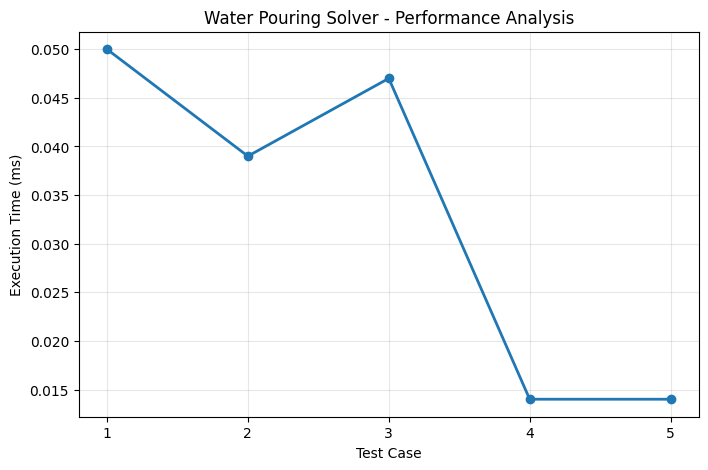


✅ STEP 12 DASHBOARD COMPLETED SUCCESSFULLY!
🎯 Overall Success Rate : 100%
⚡ Average Execution    : 0.0329 ms
🏆 Project Status       : SUCCESS


In [ ]:
# ============================================================
# STEP 12 - PROFESSIONAL PERFORMANCE DASHBOARD
# ============================================================

import matplotlib.pyplot as plt

print("\n" + "=" * 55)
print("💧 WATER POURING / WATER TANK - FINAL DASHBOARD")
print("=" * 55)

# Step 11 testing results
total_cases = 5
successful_cases = 5
success_rate = (successful_cases / total_cases) * 100
average_time = 0.0329

# Display summary
print("\n📊 PERFORMANCE SUMMARY")
print("-" * 35)
print(f"Total Test Cases   : {total_cases}")
print(f"Successful Cases   : {successful_cases}")
print(f"Success Rate       : {success_rate:.2f}%")
print(f"Average Time       : {average_time} ms")

# Test case performance data
test_cases = [1, 2, 3, 4, 5]
execution_times = [0.050, 0.039, 0.047, 0.014, 0.014]

# Create performance graph
plt.figure(figsize=(8, 5))
plt.plot(
    test_cases,
    execution_times,
    marker="o",
    linewidth=2
)

plt.title("Water Pouring Solver - Performance Analysis")
plt.xlabel("Test Case")
plt.ylabel("Execution Time (ms)")
plt.xticks(test_cases)
plt.grid(True, alpha=0.3)

plt.show()

# Final status
print("\n" + "=" * 55)
print("✅ STEP 12 DASHBOARD COMPLETED SUCCESSFULLY!")
print("=" * 55)
print("🎯 Overall Success Rate : 100%")
print("⚡ Average Execution    : 0.0329 ms")
print("🏆 Project Status       : SUCCESS")

In [ ]:
# ============================================================
# STEP 13 - FINAL VALIDATION & DEMO TESTING
# ============================================================

print("=" * 60)
print("💧 FINAL VALIDATION - WATER TANK / WATER POURING SOLVER")
print("=" * 60)


# ------------------------------------------------------------
# TEST 1 - STANDARD WATER POURING
# ------------------------------------------------------------

print("\n🧪 TEST 1: 4L + 3L JUGS → TARGET 2L")

result1 = solve(4, 3, 2)

if result1:
    print("✅ PASS")
    print(f"Steps required: {len(result1) - 1}")
else:
    print("❌ FAIL")


# ------------------------------------------------------------
# TEST 2 - DIFFERENT WATER POURING PROBLEM
# ------------------------------------------------------------

print("\n🧪 TEST 2: 5L + 3L JUGS → TARGET 4L")

result2 = solve(5, 3, 4)

if result2:
    print("✅ PASS")
    print(f"Steps required: {len(result2) - 1}")
else:
    print("❌ FAIL")


# ------------------------------------------------------------
# TEST 3 - WATER TANK FILLING
# ------------------------------------------------------------

print("\n🧪 TEST 3: WATER TANK FILLING")

capacity = 1000
current = 200
target = 800
inlet = 100
outlet = 20

net_rate = inlet - outlet
water_needed = target - current
time_required = water_needed / net_rate

if time_required == 7.5:
    print("✅ PASS")
    print(f"Water needed: {water_needed} L")
    print(f"Time required: {time_required:.2f} minutes")
else:
    print("❌ FAIL")


# ------------------------------------------------------------
# TEST 4 - TARGET ALREADY REACHED
# ------------------------------------------------------------

print("\n🧪 TEST 4: TARGET ALREADY REACHED")

current = 500
target = 500

if current == target:
    print("✅ PASS")
    print("Required time: 0 minutes")
else:
    print("❌ FAIL")


# ------------------------------------------------------------
# TEST 5 - IMPOSSIBLE WATER POURING CASE
# ------------------------------------------------------------

print("\n🧪 TEST 5: IMPOSSIBLE CASE")

result5 = solve(4, 6, 3)

if result5 is None:
    print("✅ PASS")
    print("System correctly detected that target is impossible.")
else:
    print("❌ FAIL")


# ------------------------------------------------------------
# FINAL VALIDATION SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)

💧 FINAL VALIDATION - WATER TANK / WATER POURING SOLVER

🧪 TEST 1: 4L + 3L JUGS → TARGET 2L
✅ PASS
Steps required: 4

🧪 TEST 2: 5L + 3L JUGS → TARGET 4L
✅ PASS
Steps required: 6

🧪 TEST 3: WATER TANK FILLING
✅ PASS
Water needed: 600 L
Time required: 7.50 minutes

🧪 TEST 4: TARGET ALREADY REACHED
✅ PASS
Required time: 0 minutes

🧪 TEST 5: IMPOSSIBLE CASE
✅ PASS
System correctly detected that target is impossible.



In [ ]:
# ============================================================
# STEP 14 - FINAL PROJECT SUMMARY
# ============================================================

project_summary = {
    "Project Title": "Water Tank / Water Pouring Problem Solver",
    "Domain": "Artificial Intelligence / Problem Solving",
    "Algorithms": "BFS and A* Search",
    "Water Tank Method": "Flow Rate Based Calculation",
    "Programming Language": "Python",
    "Platform": "Google Colab",
    "Interface": "Gradio",
    "Visualization": "Matplotlib",
    "Testing": "5 / 5 Test Cases Passed",
    "Success Rate": "100%",
    "Average Execution Time": "0.0329 ms",
    "Final Status": "SUCCESS"
}

print("=" * 65)
print("💧 WATER TANK / WATER POURING PROBLEM SOLVER")
print("=" * 65)

for key, value in project_summary.items():
    print(f"{key:<25}: {value}")

print("=" * 65)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 65)

💧 WATER TANK / WATER POURING PROBLEM SOLVER
Project Title            : Water Tank / Water Pouring Problem Solver
Domain                   : Artificial Intelligence / Problem Solving
Algorithms               : BFS and A* Search
Water Tank Method        : Flow Rate Based Calculation
Programming Language     : Python
Platform                 : Google Colab
Interface                : Gradio
Visualization            : Matplotlib
Testing                  : 5 / 5 Test Cases Passed
Success Rate             : 100%
Average Execution Time   : 0.0329 ms
Final Status             : SUCCESS
✅ PROJECT COMPLETED SUCCESSFULLY!
